In [43]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [44]:
import os
import sys

# In a notebook __file__ is not defined, use the current working directory instead
current_dir = os.path.dirname(os.path.abspath('.'))
if current_dir not in sys.path:
    sys.path.insert(0, current_dir)

In [45]:
from tomopt.volume import Volume

from detector_config import get_layers
from utils import draw

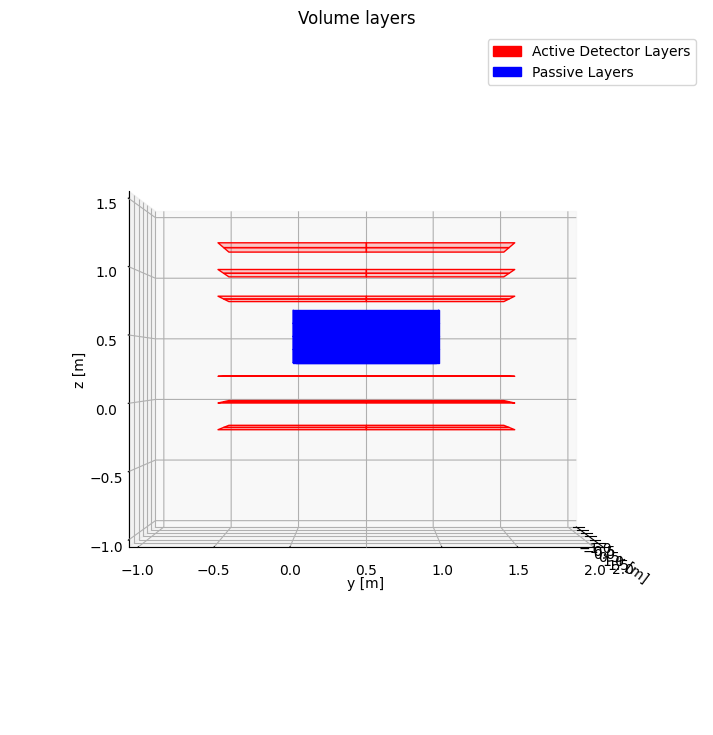

In [46]:
volume = Volume(get_layers(panel_z_spacing=0.4, n_panels=3, init_gap=0., init_res=10000, smooth=0.01))
draw(volume, xlim=[-1., 2.], ylim=[-1., 2.], zlim=[-1., 1.5], rotate = 0)

In [47]:
from functools import partial
import torch
from co_design_optimization.wrapper import CoDesignVolumeWrapper
from co_design_optimization.utility_loss import HypothesisTestLoss

wrapper = CoDesignVolumeWrapper(
    volume,
    xy_pos_opt=partial(torch.optim.SGD, lr=0),
    xy_span_opt=partial(torch.optim.SGD, lr=0),
    z_pos_opt=partial(torch.optim.SGD, lr=1e3),
    gap_opt=partial(torch.optim.SGD, lr=0),
    sigma_soft_opt=partial(torch.optim.SGD, lr=1e3),
    #loss_func=HypothesisTestLoss(debug=True),
    # Try different methods
    loss_func = HypothesisTestLoss(
        alpha=0.05,
        threshold_method='soft_sort',  # or 'smooth_max', 'quantile_regression', 'differentiable_topk'
        tau_detect=50.0,
        debug=True
    ),
    background_bs=40
)

In [48]:
from torch import Tensor
from tomopt.core import X0
from tomopt.optimisation.data import PassiveYielder

bkg_mat = 'aluminium'
block_mat = 'uranium'

def cubes_rad_length(*, z: float, lw: Tensor, size: float, signal: bool = False) -> Tensor:
    rad_length = torch.ones(list((lw / size).long())) * X0[bkg_mat]
    grid = torch.zeros_like(rad_length)

    cube_size = 1
    offset = 2
    if signal and (z > 0.3 and z < 0.5):
        grid[-offset - cube_size : -offset, offset : offset + cube_size] = X0[block_mat]
        rad_length[grid.bool()] = grid[grid.bool()]

    return rad_length

# Create passive material for the volume
passives = PassiveYielder([lambda **kwargs: cubes_rad_length(**kwargs, signal=False)]*40 + [lambda **kwargs: cubes_rad_length(**kwargs, signal=True)]*40)

1 warmup callbacks found, with a total warmup period of 2 epochs.


Loss: -0.020622 | Power: 0.3541 | Sigma_soft: 0.000500 | Sigma_hw: 0.016917 | Tc: 0.090258 | Method: soft_sort


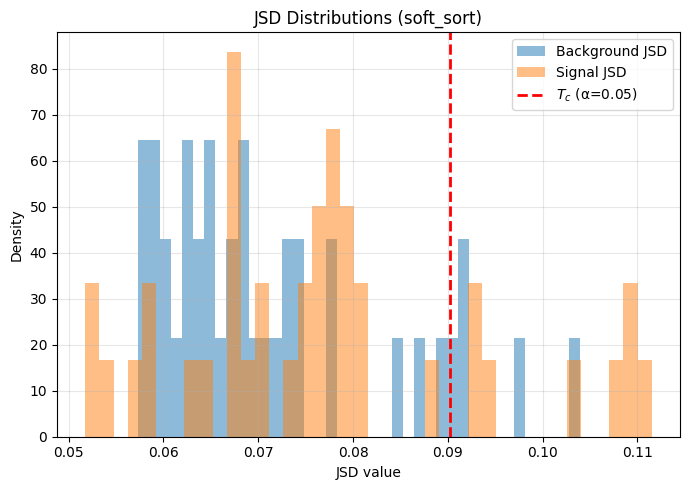

Epoch 1 Volume: 79: Loss = -0.0206, state=train
Parameter containing:
tensor([0.5000, 0.5000], requires_grad=True)
Parameter containing:
tensor([0.5000, 0.5000], requires_grad=True)
Parameter containing:
tensor([0.5000, 0.5000], requires_grad=True)
Parameter containing:
tensor([0.5000, 0.5000], requires_grad=True)
Parameter containing:
tensor([0.5000, 0.5000], requires_grad=True)
Parameter containing:
tensor([0.5000, 0.5000], requires_grad=True)
Parameter containing:
tensor([1.2000], requires_grad=True)
Parameter containing:
tensor([1.], requires_grad=True)
Parameter containing:
tensor([0.8000], requires_grad=True)
Parameter containing:
tensor([0.2000], requires_grad=True)
Parameter containing:
tensor([0.], requires_grad=True)
Parameter containing:
tensor([-0.2000], requires_grad=True)
Parameter containing:
tensor([2., 2.], requires_grad=True)
Parameter containing:
tensor([2., 2.], requires_grad=True)
Parameter containing:
tensor([2., 2.], requires_grad=True)
Parameter containing:
tens

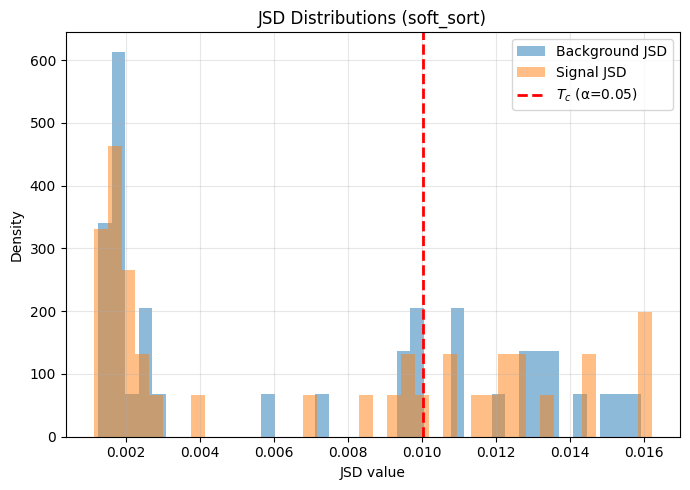

Epoch 1 Volume: 79: Loss = -0.1804, state=valid
exiting training epoch
Loss: -0.030844 | Power: 0.4937 | Sigma_soft: 0.000500 | Sigma_hw: 0.015751 | Tc: 0.064995 | Method: soft_sort


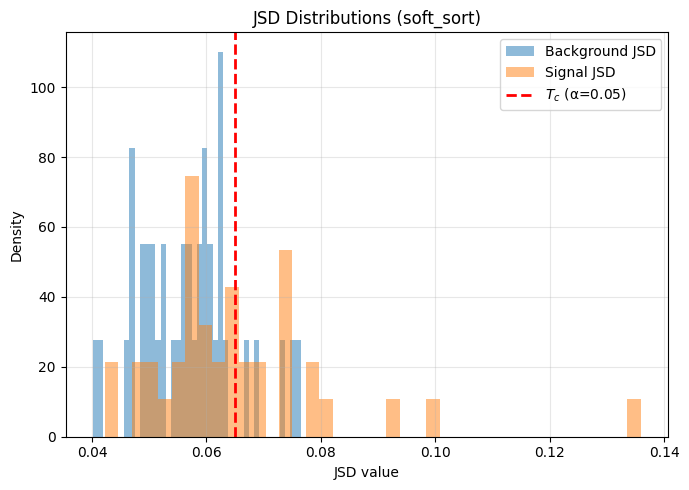

Epoch 2 Volume: 79: Loss = -0.0308, state=train
Parameter containing:
tensor([0.5000, 0.5000], requires_grad=True)
Parameter containing:
tensor([0.5000, 0.5000], requires_grad=True)
Parameter containing:
tensor([0.5000, 0.5000], requires_grad=True)
Parameter containing:
tensor([0.5000, 0.5000], requires_grad=True)
Parameter containing:
tensor([0.5000, 0.5000], requires_grad=True)
Parameter containing:
tensor([0.5000, 0.5000], requires_grad=True)
Parameter containing:
tensor([1.1992], requires_grad=True)
Parameter containing:
tensor([1.], requires_grad=True)
Parameter containing:
tensor([0.8003], requires_grad=True)
Parameter containing:
tensor([0.1997], requires_grad=True)
Parameter containing:
tensor([0.], requires_grad=True)
Parameter containing:
tensor([-0.2000], requires_grad=True)
Parameter containing:
tensor([2., 2.], requires_grad=True)
Parameter containing:
tensor([2., 2.], requires_grad=True)
Parameter containing:
tensor([2., 2.], requires_grad=True)
Parameter containing:
tens

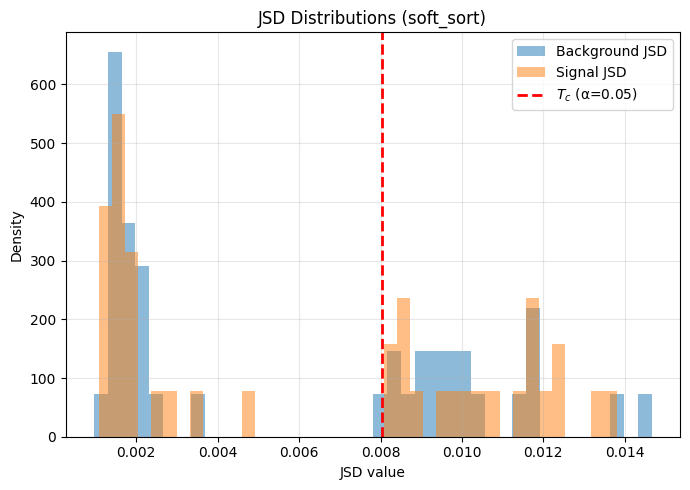

Epoch 2 Volume: 79: Loss = -0.1896, state=valid
exiting training epoch
Loss: -0.020974 | Power: 0.3763 | Sigma_soft: 0.000500 | Sigma_hw: 0.017689 | Tc: 0.080762 | Method: soft_sort


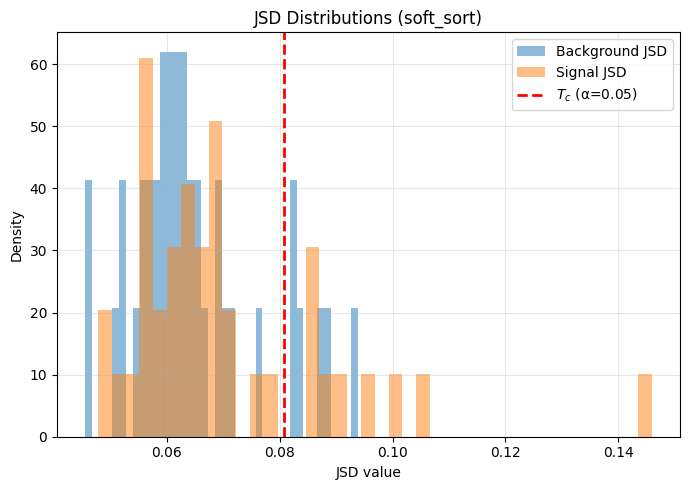

Epoch 3 Volume: 79: Loss = -0.0210, state=train
=== Gradient check ===
Optimizer: xy_pos_opt
  Param 0: grad norm = 0.00018750857270788401
  Param 1: grad norm = 6.723520982632181e-06
  Param 2: grad norm = 0.00021904734603594989
  Param 3: grad norm = 108.5828628540039
  Param 4: grad norm = 49.66301727294922
  Param 5: grad norm = 0.0002633461554069072
Optimizer: z_pos_opt
  Param 0: grad norm = 2.371356248855591
  Param 1: grad norm = 0.3313184678554535
  Param 2: grad norm = 2.7026782035827637
  Param 3: grad norm = 42.83122634887695
  Param 4: grad norm = 4.101391315460205
  Param 5: grad norm = 0.4882199764251709
Optimizer: xy_span_opt
  Param 0: grad norm = 3.971079877373995e-06
  Param 1: grad norm = 5.256858344182547e-07
  Param 2: grad norm = 7.620743417646736e-06
  Param 3: grad norm = 157.6824951171875
  Param 4: grad norm = 118.09613800048828
  Param 5: grad norm = 0.00024146295618265867
Optimizer: gap_opt
  Param 0: grad norm = 0.000692168134264648
  Param 1: grad norm = 

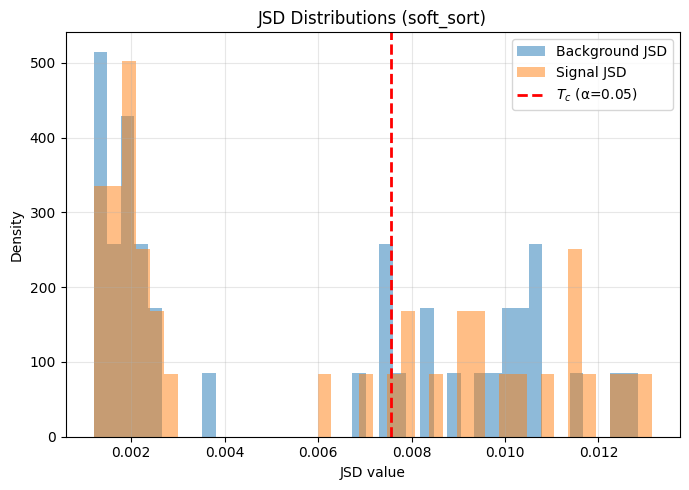

Epoch 3 Volume: 79: Loss = -0.4050, state=valid
exiting training epoch


In [ ]:
from tomopt.optimisation import CostCoefWarmup, OptConfig, MuonResampler, HitRecord
from callbacks import PanelMetricLogger, SigmoidPanelSmoothnessSchedule
from co_design_optimization.callbacks import HypothesisTestCallback
_ = wrapper.fit(n_epochs=20,  # Run for 10 epochs (5+5 are warmup epochs)""
                passive_bs=80,  # Update every passive volumes (we only have one)
                n_mu_per_volume=5000,  # Use 1000 per passive volume
                mu_bs=1000,  # Run the 1000 muons per volume in 10 batchesnomorenans' of 100 muons (quicker than a single batch of 1000)
                trn_passives=passives,
                val_passives=passives,  # Evaluate on the training data
                cbs=[ HypothesisTestCallback(),
                    #PanelUpdateLimiter(max_z_step=0.01),
                    #CostCoefWarmup(n_warmup=0),
                    OptConfig(n_warmup=2, rates={'xy_pos_opt':0, 'z_pos_opt':0.1, 'xy_span_opt':0.0, 'gap_opt':0.0, 'sigma_soft_opt':0.1}),
                    MuonResampler(),
                    #PanelMetricLogger(),
                    
                    SigmoidPanelSmoothnessSchedule((0.1, 0.001))
                
                    
                    ]) 

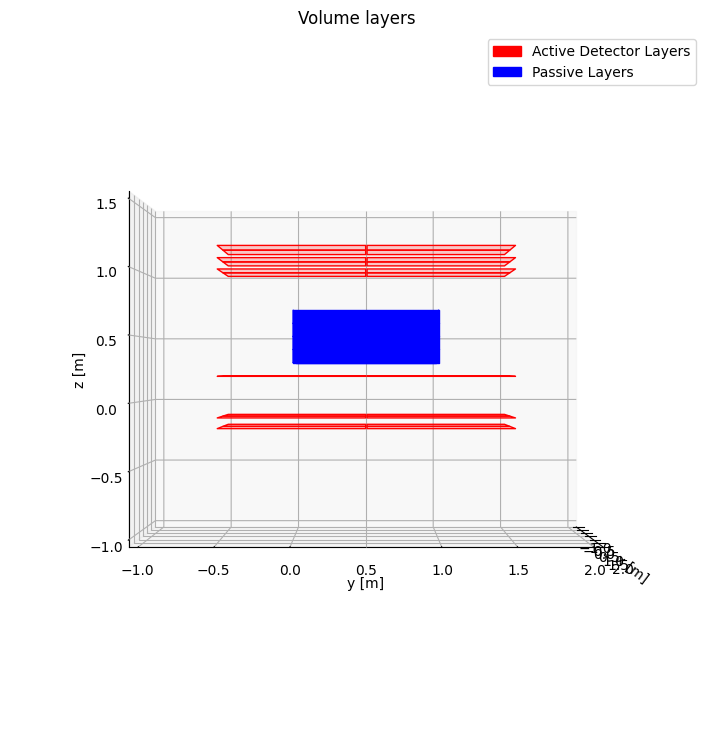

In [ ]:
draw(volume, xlim=[-1., 2.], ylim=[-1., 2.], zlim=[-1., 1.5], rotate = 0)

In [ ]:
wrapper.loss_func.sigma_soft

tensor(0.0002, grad_fn=<ExpBackward0>)

In [ ]:
wrapper.loss_func.angular_res

tensor(0.0005, grad_fn=<MeanBackward0>)